Production notebook for interacting with the 2D Gutzwiller Expansion Code.  Theory is in "Gutz2DExpansion.ipynb".

# Load Program

In [101]:
include("Expansion-4.jl")

rotshadowplot! (generic function with 1 method)

# Run Interactive Visualization

In [58]:
GLMakie.activate!(inline=false)
vz=expansionviz();

In [59]:
vz.times

692-element Vector{Float64}:
  0.02
  0.04
  0.060000000000000005
  0.08
  0.09999999999999999
  0.11999999999999998
  0.13999999999999999
  0.16
  0.18000000000000002
  0.20000000000000004
  0.22000000000000006
  0.24000000000000007
  0.26000000000000006
  ⋮
 13.619999999999754
 13.639999999999754
 13.659999999999753
 13.679999999999753
 13.699999999999752
 13.719999999999752
 13.739999999999752
 13.759999999999751
 13.77999999999975
 13.79999999999975
 13.81999999999975
 13.83999999999975

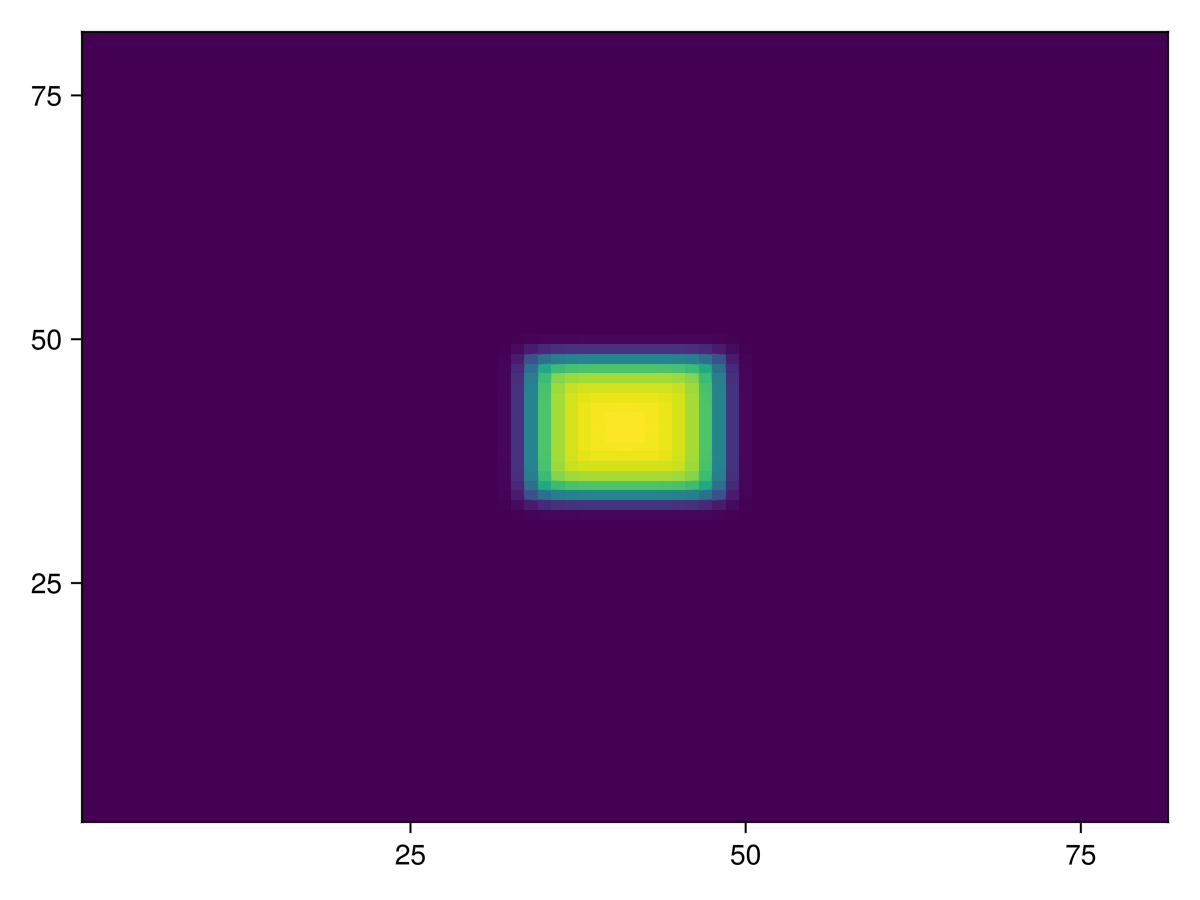

In [61]:
heatmap(density(vz.data[1]))

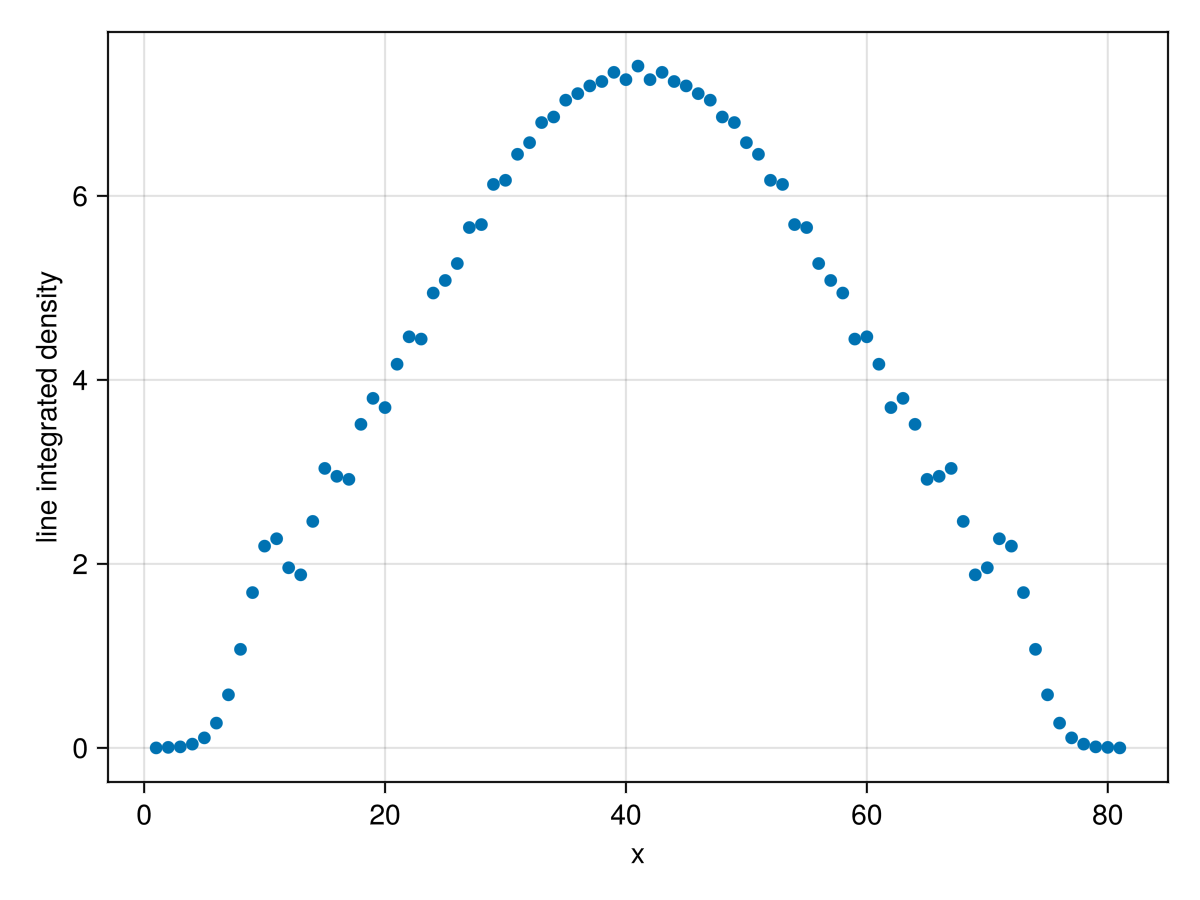

In [69]:
scatter(intdens(vz.data[end]);
axis=(;xlabel="x",ylabel="line integrated density")
)

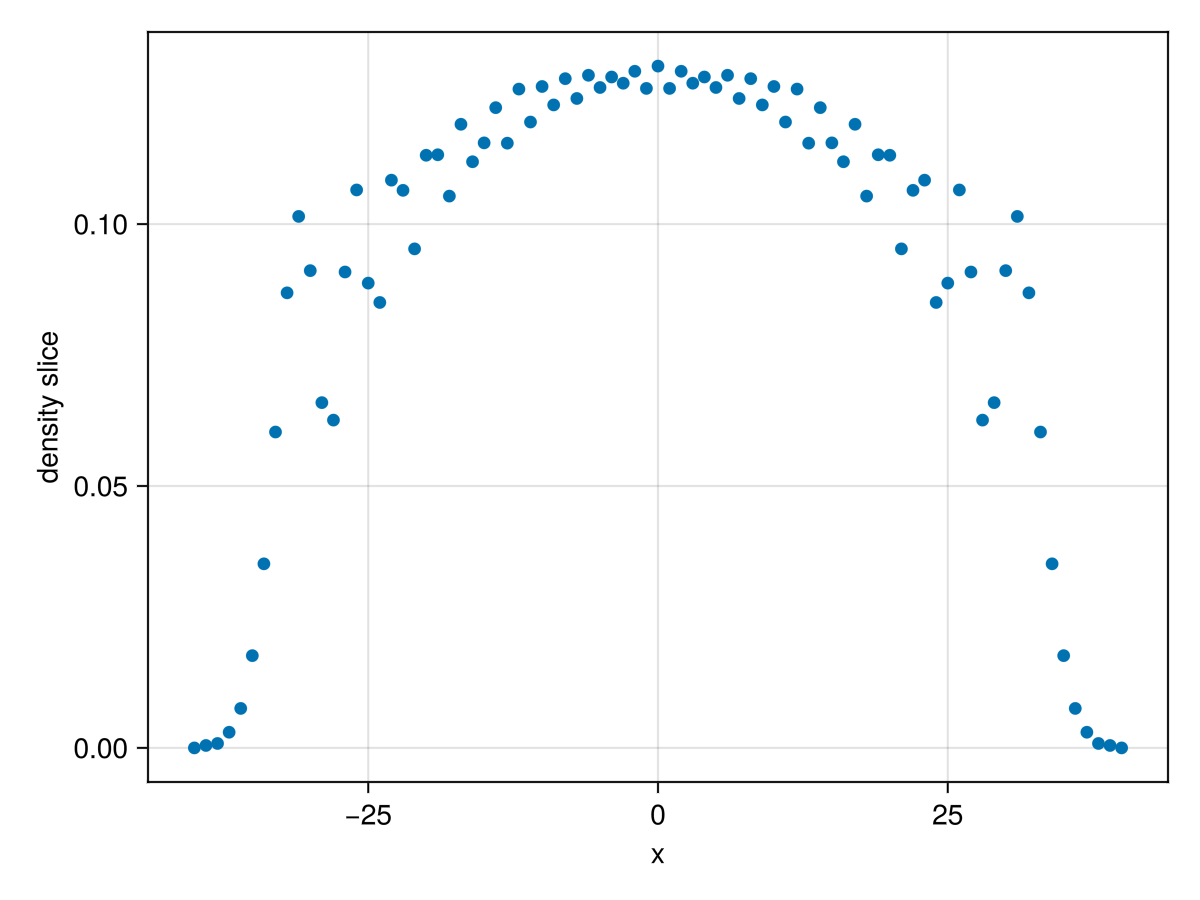

In [70]:
scatter(density(vz.data[end])[:,0];
axis=(;xlabel="x",ylabel="density slice")
)

In [29]:
sliderplot(vz)

GLMakie.Screen(...)

In [87]:
axes(vz.data[1])[1]

OffsetArrays.IdOffsetRange(values=-40:40, indices=-40:40)

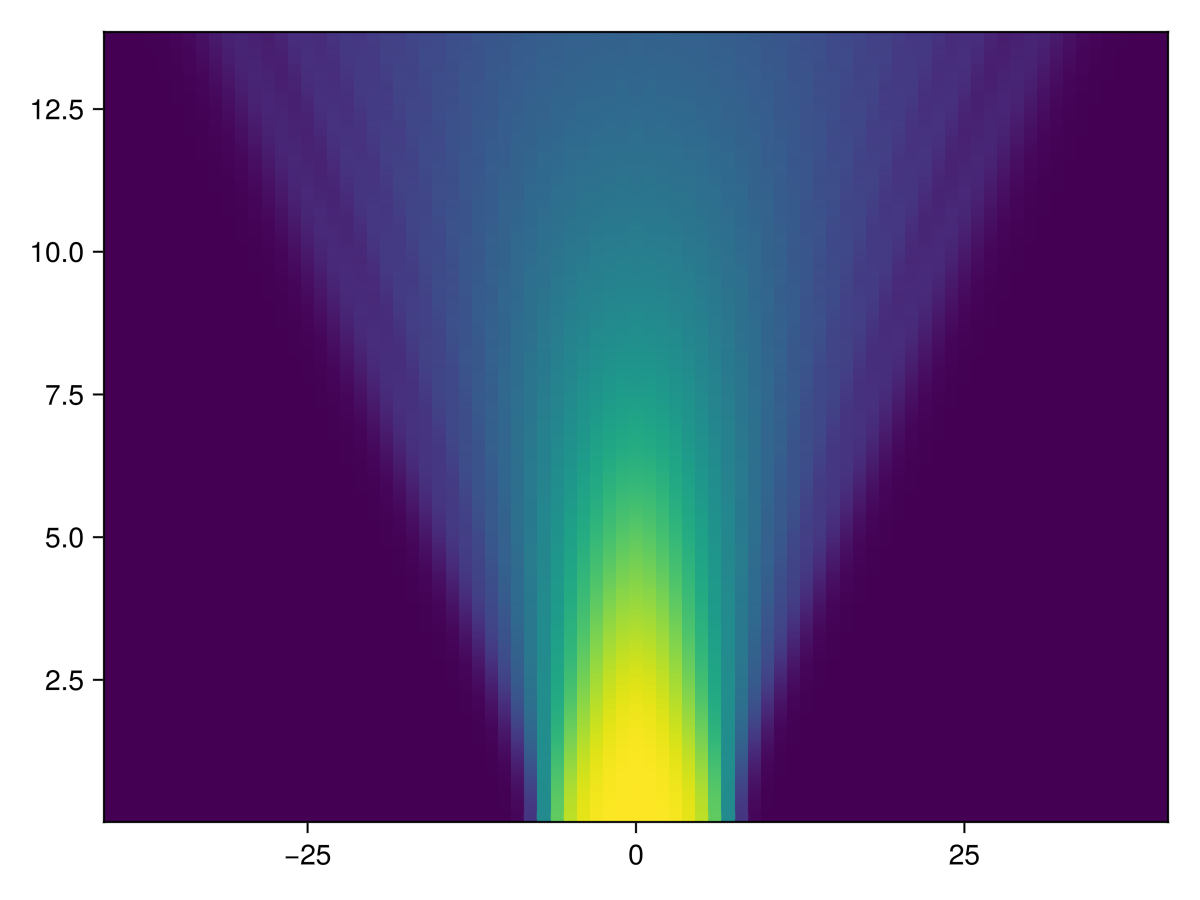

In [91]:
shadowplot(vz)

# Batch

In [31]:
function omegasweep(f0;dg,omegas,dη,η,delta,dt,iterations,storef,storeinterval,adaptive)
    evs=[]
    for (i,ω) in enumerate(omegas)
        print("ω=$ω ")
        f=copy(f0)
        ev=evolve!(f;dg=dg,ω=ω,dη=dη,η=η,delta=delta,
            dt=dt,iterations=iterations,storef=storef,storeinterval=storeinterval,adaptive=adaptive)
        push!(evs,ev)
    end
    return evs
end

omegasweep (generic function with 1 method)

In [51]:
@time f0=initialize(40,12,5,[0.1,0.9,0,0,0,0])
f1=copy(f0)
@time relaxrun=relax!(f1;η=8.,
    delta=Static(squarebilliardpotential(
        #=L=#40,#=R=#10.,#=s=#2.,#=V=#10.)),
    dt=0.01,storeE=true,storef=true);

  0.000845 seconds (39.39 k allocations: 3.614 MiB)
  2.643753 seconds (2.22 k allocations: 325.682 MiB, 13.60% gc time)


In [52]:
sliderplot(relaxrun.flist)

GLMakie.Screen(...)

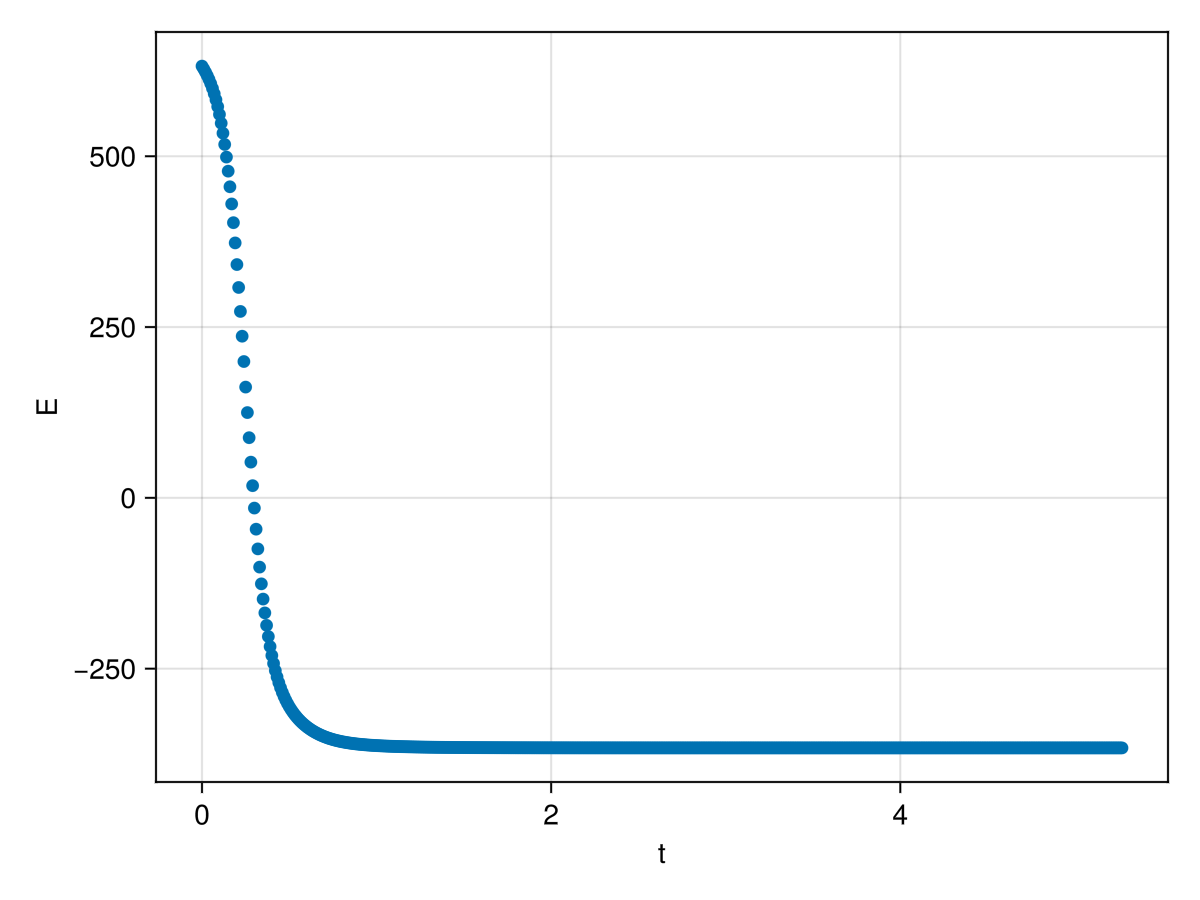

In [53]:
plot(relaxrun.Elist.times,relaxrun.Elist.data;
axis=(;xlabel="t",ylabel="E"))

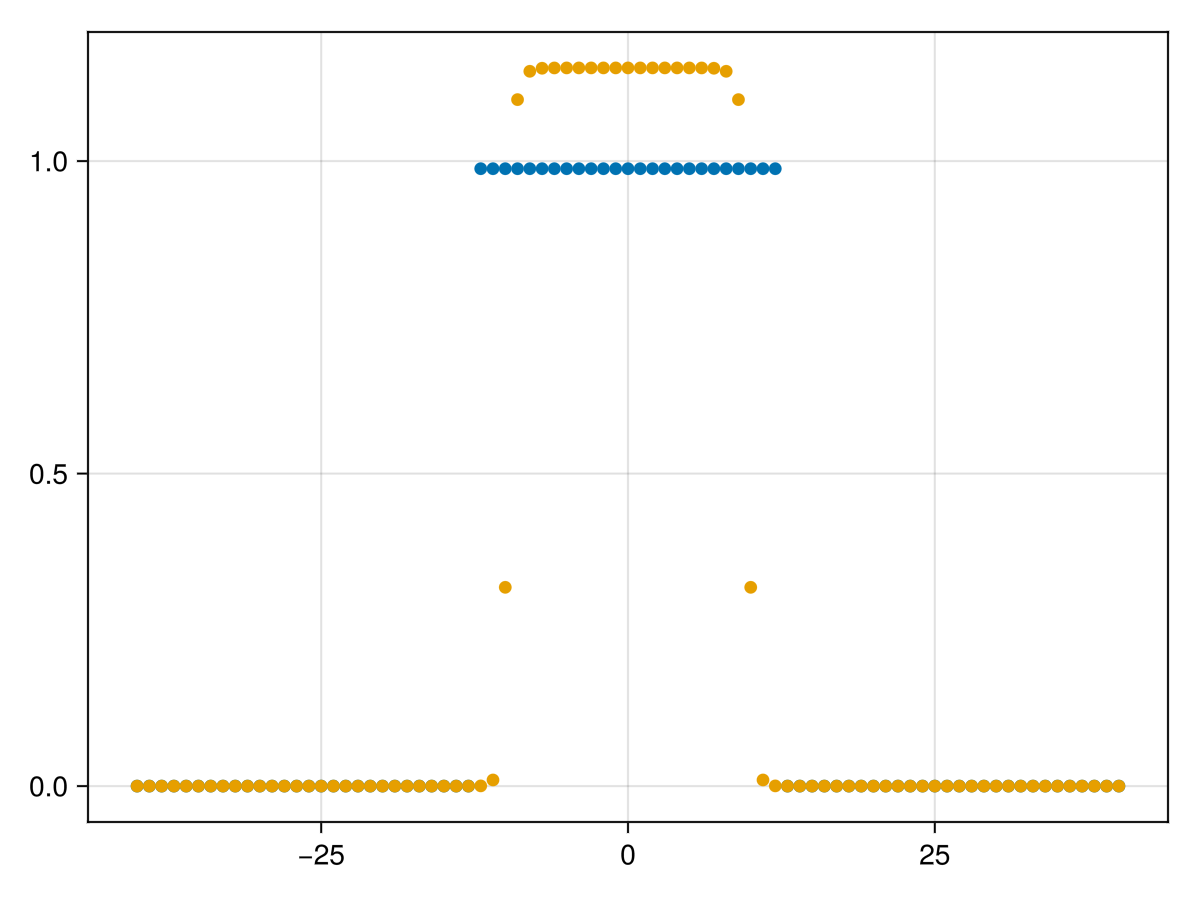

In [54]:
fig=Figure()
ax=Axis(fig[1,1])
scatter!(ax,density(f0)[0,:],label="before")
scatter!(ax,density(f1)[0,:],label="relaxed")
fig

In [71]:
omegas=0:0.1:12
@time sweeps=omegasweep(f0;dg=0.1,omegas=omegas,dη=0.1,η=8.,
    delta=CAScalar(0.0),
    dt=0.01,iterations=1000,storef=true,storeinterval=10,adaptive=false);

ω=0.0 ω=0.1 ω=0.2 ω=0.3 ω=0.4 ω=0.5 ω=0.6 ω=0.7 ω=0.8 ω=0.9 ω=1.0 ω=1.1 ω=1.2 ω=1.3 ω=1.4 ω=1.5 ω=1.6 ω=1.7 ω=1.8 ω=1.9 ω=2.0 ω=2.1 ω=2.2 ω=2.3 ω=2.4 ω=2.5 ω=2.6 ω=2.7 ω=2.8 ω=2.9 ω=3.0 ω=3.1 ω=3.2 ω=3.3 ω=3.4 ω=3.5 ω=3.6 ω=3.7 ω=3.8 ω=3.9 ω=4.0 ω=4.1 ω=4.2 ω=4.3 ω=4.4 ω=4.5 ω=4.6 ω=4.7 ω=4.8 ω=4.9 ω=5.0 ω=5.1 ω=5.2 ω=5.3 ω=5.4 ω=5.5 ω=5.6 ω=5.7 ω=5.8 ω=5.9 ω=6.0 ω=6.1 ω=6.2 ω=6.3 ω=6.4 ω=6.5 ω=6.6 ω=6.7 ω=6.8 ω=6.9 ω=7.0 ω=7.1 ω=7.2 ω=7.3 ω=7.4 ω=7.5 ω=7.6 ω=7.7 ω=7.8 ω=7.9 ω=8.0 ω=8.1 ω=8.2 ω=8.3 ω=8.4 ω=8.5 ω=8.6 ω=8.7 ω=8.8 ω=8.9 ω=9.0 ω=9.1 ω=9.2 ω=9.3 ω=9.4 ω=9.5 ω=9.6 ω=9.7 ω=9.8 ω=9.9 ω=10.0 ω=10.1 ω=10.2 ω=10.3 ω=10.4 ω=10.5 ω=10.6 ω=10.7 ω=10.8 ω=10.9 ω=11.0 ω=11.1 ω=11.2 ω=11.3 ω=11.4 ω=11.5 ω=11.6 ω=11.7 ω=11.8 ω=11.9 ω=12.0 440.630605 seconds (5.64 M allocations: 80.262 GiB, 1.09% gc time, 0.13% compilation time)


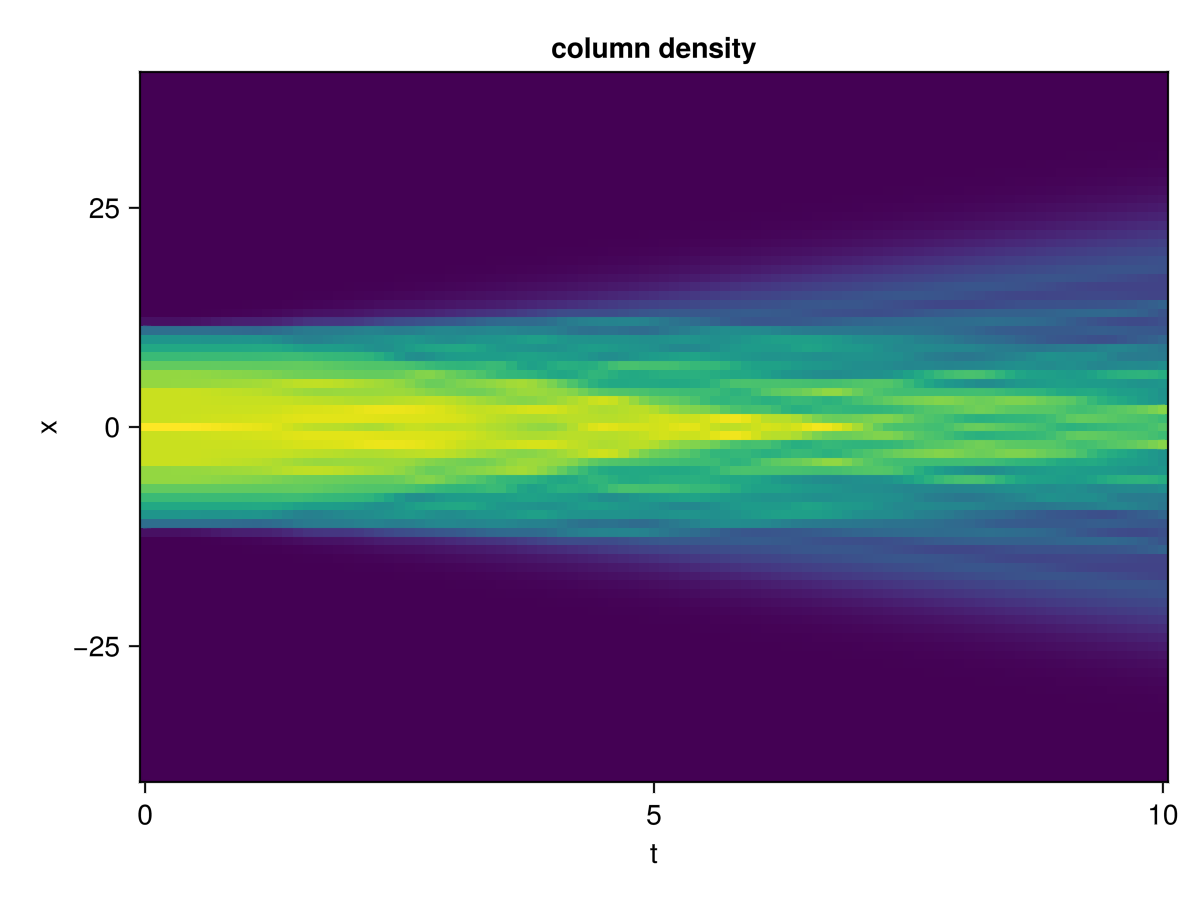

In [100]:
rotshadowplot(sweeps[2].flist;axis=(;xlabel="t",ylabel="x",title="column density"))

In [112]:
string(2.3)

"2.3"

In [125]:
(pairs(1:10))[1:2:10]

1:2:9

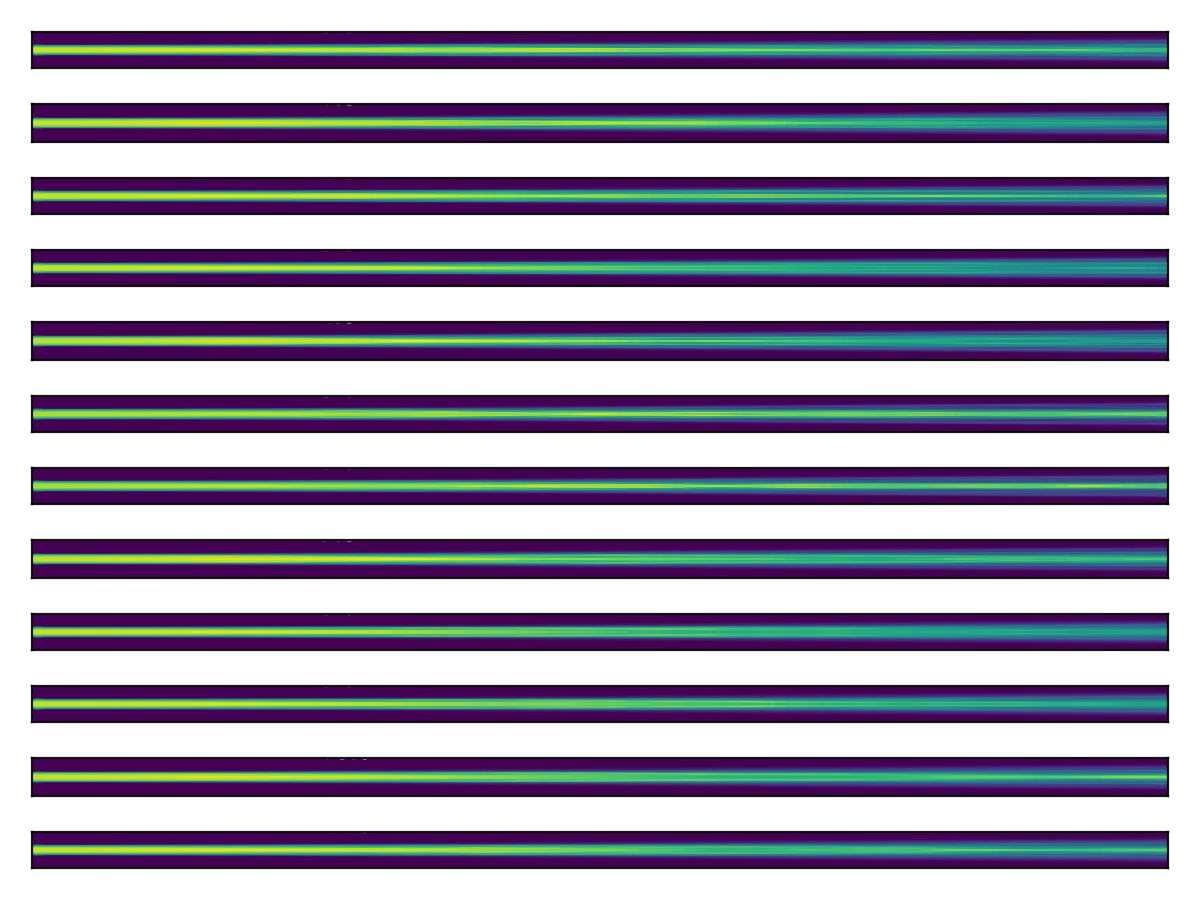

In [131]:
fig=Figure()
i=1
for (j,sweep) in pairs(sweeps)
    if mod(j,10)!=0
        continue
    end
    omega=omegas[j]
    ax=Axis(fig[i,1]#=;xlabel="t",ylabel="x"=#)
    hidedecorations!(ax)
    rotshadowplot!(ax,sweep.flist)
    text!(ax,(2.5,25);text=string(omega),color=:white)
    i+=1
end
fig

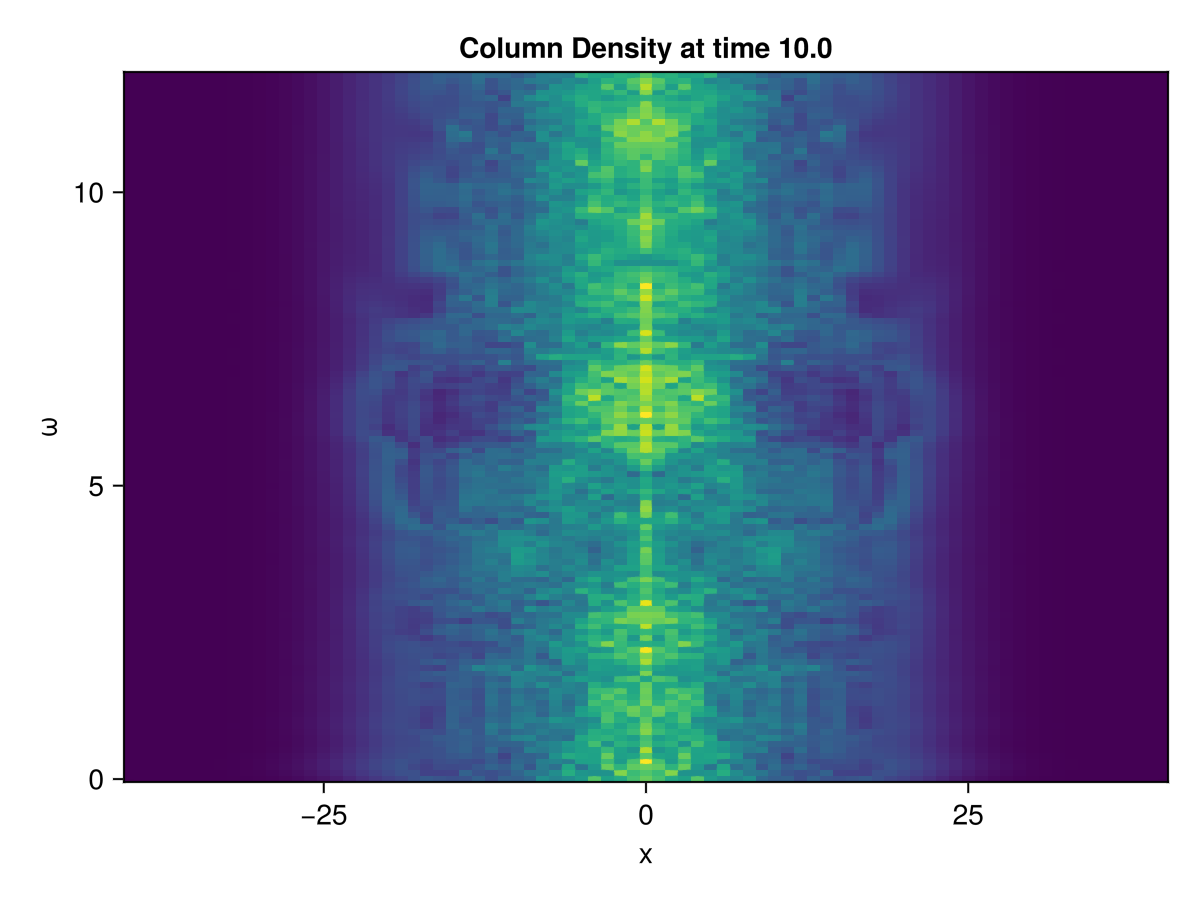

In [139]:
finalslice=stack([intdens(s.flist.data[end]) for s in sweeps])
time=sweeps[1].flist.times[end]
xvals=collect(axes(sweeps[1].flist.data[1])[1])
heatmap(xvals,omegas,finalslice;axis=(;xlabel="x",ylabel="ω",title="Column Density at time $time"))

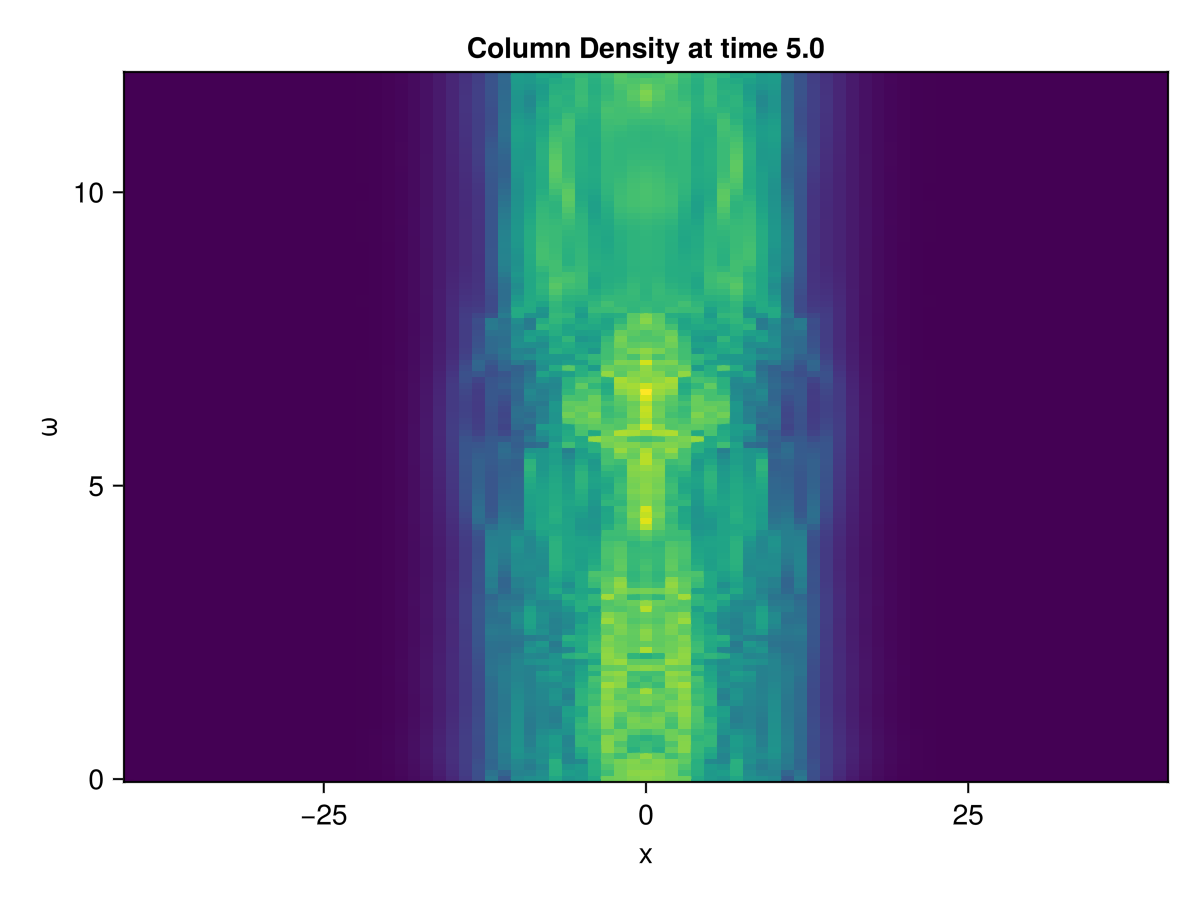

In [145]:
slicenum=51
finalslice=stack([intdens(s.flist.data[slicenum]) for s in sweeps])
time=sweeps[1].flist.times[slicenum]
xvals=collect(axes(sweeps[1].flist.data[1])[1])
heatmap(xvals,omegas,finalslice;axis=(;xlabel="x",ylabel="ω",title="Column Density at time $time"))